# Text Classification - BBC Dataset
## Comparison of Text Representations and Classification Algorithms

This notebook implements and compares different approaches for BBC text classification:
- **Representations**: TF-IDF, BERT
- **Algorithms**: Logistic Regression, SVM, Random Forest
- **Target**: Predicting the **label** variable


In [1]:
from pathlib import Path
import os

# Detect Colab
IN_COLAB = "COLAB_GPU" in os.environ

if IN_COLAB:
    from google.colab import drive
    drive.mount("/content/drive")
    PROJECT_ROOT = Path("/content/drive/MyDrive/Text_Mining_Project")
else:
    PROJECT_ROOT = Path.cwd()
    if PROJECT_ROOT.name == "notebooks":
        PROJECT_ROOT = PROJECT_ROOT.parent

DATA_DIR = PROJECT_ROOT / "data"
RAW_DIR = DATA_DIR / "raw"
PROCESSED_DIR = DATA_DIR / "processed"

print("PROJECT_ROOT:", PROJECT_ROOT)
print("RAW_DIR:", RAW_DIR)
print("PROCESSED_DIR:", PROCESSED_DIR)

Mounted at /content/drive
PROJECT_ROOT: /content/drive/MyDrive/Text_Mining_Project
RAW_DIR: /content/drive/MyDrive/Text_Mining_Project/data/raw
PROCESSED_DIR: /content/drive/MyDrive/Text_Mining_Project/data/processed


## 2. Import Libraries

---






In [2]:
# import libraries
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report
import warnings
warnings.filterwarnings('ignore')

# other viz settings
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
%matplotlib inline


## 4. Data Loading

---



In [3]:
print("Loading data...")

bbc_df = pd.read_pickle(PROCESSED_DIR / "df_bbc_preprocessed.pkl")

print(f"\nDataframe shape: {bbc_df.shape}")
print(f"Available columns: {bbc_df.columns.tolist()}")
print(f"\nFirst 5 rows:")
display(bbc_df.head())
print(f"\nLabel distribution:")
print(bbc_df["label"].value_counts())



Loading data...

Dataframe shape: (2232, 7)
Available columns: ['text', 'label', 'length', 'clean_text_bow', 'clean_text_bert', 'bow_length', 'bert_length']

First 5 rows:


,text,label,length,clean_text_bow,clean_text_bert,bow_length,bert_length
0,Swap offer for pirated Windows XP\n\nComputer ...,tech,353,swap offer pirated window xp computer giant mi...,Swap offer for pirated Windows XP Computer gia...,212,353
1,DS aims to touch gamers\n\nThe mobile gaming i...,tech,567,ds aim touch gamer mobile gaming industry set ...,DS aims to touch gamers The mobile gaming indu...,318,567
2,Digital guru floats sub-$100 PC\n\nNicholas Ne...,tech,464,digital guru float sub pc nicholas negroponte ...,Digital guru floats sub-$100 PC Nicholas Negro...,240,464
3,The Force is strong in Battlefront\n\nThe warm...,tech,651,force strong battlefront warm reception greet ...,The Force is strong in Battlefront The warm re...,355,651
4,US blogger fired by her airline\n\nA US airlin...,tech,560,us blogger fire airline us airline attendant s...,US blogger fired by her airline A US airline a...,308,560



Label distribution:
label
business         517
sport            511
politics         417
tech             401
entertainment    386
Name: count, dtype: int64


In [4]:
print("\nLoading TF-IDF embeddings...")
X_all_tfidf = joblib.load(PROCESSED_DIR / "X_all_tfidf.joblib")
print(f"TF-IDF shape: {X_all_tfidf.shape}")

print("\nLoading BERT embeddings...")
embeddings_bert = np.load(PROCESSED_DIR / "embeddings_all.npy")
print(f"BERT shape: {embeddings_bert.shape}")




Loading TF-IDF embeddings...
TF-IDF shape: (2232, 6985)

Loading BERT embeddings...
BERT shape: (2232, 384)


## 5. Data Quality checks

---







In [5]:
# check that dimensions match
n_samples = len(bbc_df)
print(f'Number of samples in the dataframe: {n_samples}')
print(f'Number of TF-IDF samples: {X_all_tfidf.shape[0]}')
print(f'Number of BERT samples: {embeddings_bert.shape[0]}')

if n_samples == X_all_tfidf.shape[0] == embeddings_bert.shape[0]:
    print('\nAll dimensions match!')
else:
    print('\nWARNING: Dimensions do not match!')


Number of samples in the dataframe: 2232
Number of TF-IDF samples: 2232
Number of BERT samples: 2232

All dimensions match!


## 6. Data Preparetion

---






In [6]:
# extract labels
y = bbc_df['label'].values

# embeddings
embeddings = {
    'TF-IDF': X_all_tfidf,
    'BERT': embeddings_bert
}

print('Available embeddings:')
for name, emb in embeddings.items():
    print(f'  {name:15s}: {emb.shape}')

print(f'\nLabel shape: {y.shape}')
print(f'Unique classes: {np.unique(y)}')


Available embeddings:
  TF-IDF         : (2232, 6985)
  BERT           : (2232, 384)

Label shape: (2232,)
Unique classes: ['business' 'entertainment' 'politics' 'sport' 'tech']


## 7. Split Train/Test

---



In [7]:
# split for each embedding
X_train = {}
X_test = {}
test_size = 0.2
random_state = 42

for name, X in embeddings.items():
    X_tr, X_te, y_tr, y_te = train_test_split(
        X, y, test_size=test_size, random_state=random_state, stratify=y
    )
    X_train[name] = X_tr
    X_test[name] = X_te
    print(f'{name:15s}: Train {X_tr.shape}, Test {X_te.shape}')

# Labels  for all embeddings
_, _, y_train, y_test = train_test_split(
    embeddings['TF-IDF'], y, test_size=test_size, random_state=random_state, stratify=y
)

print(f'\nLabels: Train {y_train.shape}, Test {y_test.shape}')


TF-IDF         : Train (1785, 6985), Test (447, 6985)
BERT           : Train (1785, 384), Test (447, 384)

Labels: Train (1785,), Test (447,)


## 8. Models definition

---



In [8]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42, n_jobs=-1),
    'SVM': SVC(kernel='rbf', random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
}

print('Configured models:')
for name in models.keys():
    print(f'  - {name}')


Configured models:
  - Logistic Regression
  - SVM
  - Random Forest


In [9]:
# evaluation and training function
def evaluate_model(model, X_train, X_test, y_train, y_test):

    # training
    model.fit(X_train, y_train)

    # predictions
    y_pred = model.predict(X_test)

    # metrics
    accuracy = accuracy_score(y_test, y_pred)
    macro_f1 = f1_score(y_test, y_pred, average='macro')
    cm = confusion_matrix(y_test, y_pred)

    return {
        'accuracy': accuracy,
        'macro_f1': macro_f1,
        'confusion_matrix': cm,
        'predictions': y_pred
    }


## 9. Training and evaluetion

---



In [10]:
# results dictionary
results = {}

print('='*80)
print('MODEL TRAINING AND EVALUATION')
print('='*80)

# loop over embeddings and models
for emb_name in embeddings.keys():
    print(f'\n{"="*80}')
    print(f'Embedding: {emb_name}')
    print(f'{"="*80}')

    results[emb_name] = {}

    for model_name, model in models.items():
        print(f'\n  → {model_name}...')

        # Evaluation
        res = evaluate_model(
            model,
            X_train[emb_name],
            X_test[emb_name],
            y_train,
            y_test
        )

        results[emb_name][model_name] = res

        print(f'     Accuracy:  {res["accuracy"]:.4f}')
        print(f'     Macro F1:  {res["macro_f1"]:.4f}')

print(f'\n{"="*80}')
print('TRAINING COMPLETED')
print('='*80)


MODEL TRAINING AND EVALUATION

Embedding: TF-IDF

  → Logistic Regression...
     Accuracy:  0.9776
     Macro F1:  0.9774

  → SVM...
     Accuracy:  0.9799
     Macro F1:  0.9799

  → Random Forest...
     Accuracy:  0.9799
     Macro F1:  0.9793

Embedding: BERT

  → Logistic Regression...
     Accuracy:  0.9709
     Macro F1:  0.9704

  → SVM...
     Accuracy:  0.9732
     Macro F1:  0.9727

  → Random Forest...
     Accuracy:  0.9441
     Macro F1:  0.9435

TRAINING COMPLETED


## 10. Results

In [11]:
data = []
for emb_name, model_results in results.items():
    for model_name, metrics in model_results.items():
        data.append({
            'Embedding': emb_name,
            'Model': model_name,
            'Accuracy': metrics['accuracy'],
            'Macro F1': metrics['macro_f1']
        })

summary_df = pd.DataFrame(data)

print('\n' + '='*80)
print('SUMMARY RESULTS')
print('='*80)
print(summary_df.to_string(index=False))

# best configuration
best = summary_df.loc[summary_df['Macro F1'].idxmax()]
print(f'\n BEST CONFIGURATION:')
print(f'   Embedding: {best["Embedding"]}')
print(f'   Model: {best["Model"]}')
print(f'   Accuracy: {best["Accuracy"]:.4f}')
print(f'   Macro F1: {best["Macro F1"]:.4f}')



SUMMARY RESULTS
Embedding               Model  Accuracy  Macro F1
   TF-IDF Logistic Regression  0.977629  0.977367
   TF-IDF                 SVM  0.979866  0.979857
   TF-IDF       Random Forest  0.979866  0.979269
     BERT Logistic Regression  0.970917  0.970408
     BERT                 SVM  0.973154  0.972710
     BERT       Random Forest  0.944072  0.943543

 BEST CONFIGURATION:
   Embedding: TF-IDF
   Model: SVM
   Accuracy: 0.9799
   Macro F1: 0.9799


## 11. Heatmaps

---



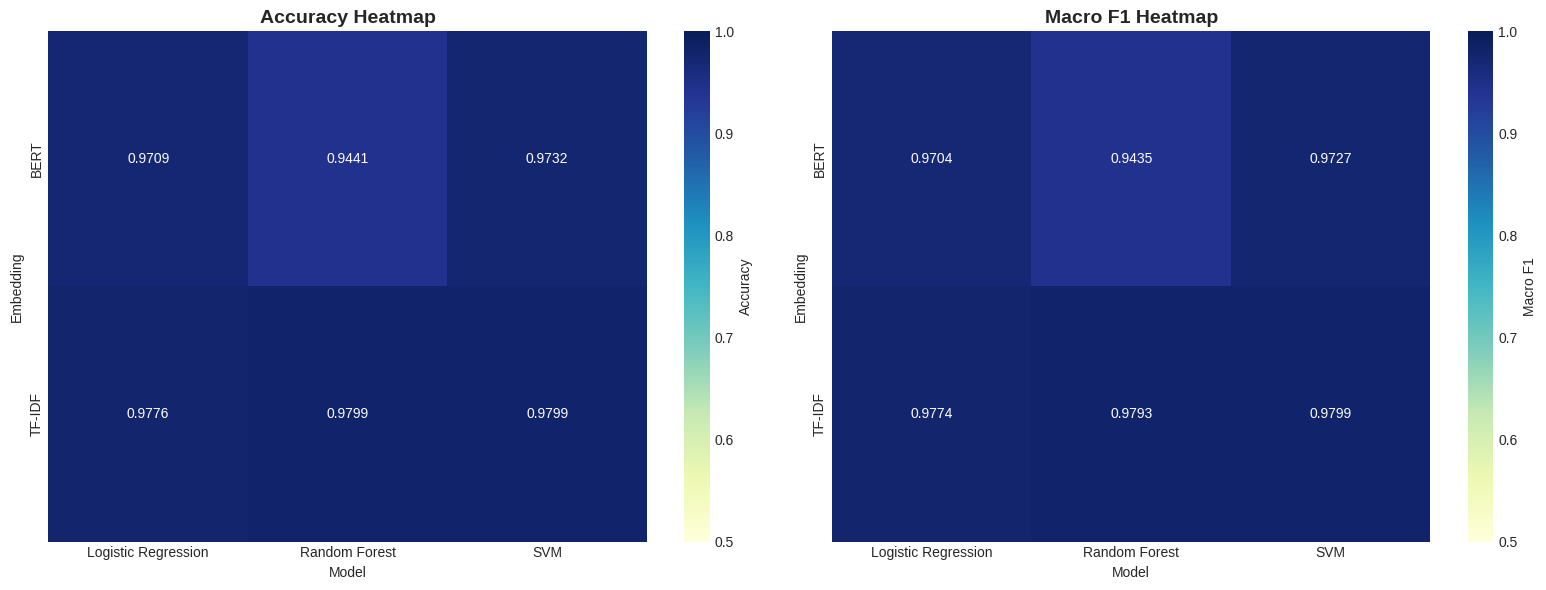

In [12]:
# metrics heatmap
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# accuracy
pivot_acc = summary_df.pivot(index='Embedding', columns='Model', values='Accuracy')
sns.heatmap(pivot_acc, annot=True, fmt='.4f', cmap='YlGnBu', ax=axes[0],
            cbar_kws={'label': 'Accuracy'}, vmin=0.5, vmax=1.0)
axes[0].set_title('Accuracy Heatmap', fontsize=14, fontweight='bold')

# Macro F1
pivot_f1 = summary_df.pivot(index='Embedding', columns='Model', values='Macro F1')
sns.heatmap(pivot_f1, annot=True, fmt='.4f', cmap='YlGnBu', ax=axes[1],
            cbar_kws={'label': 'Macro F1'}, vmin=0.5, vmax=1.0)
axes[1].set_title('Macro F1 Heatmap', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()


## 12. Confusion Matrix of the Best Configuration

---



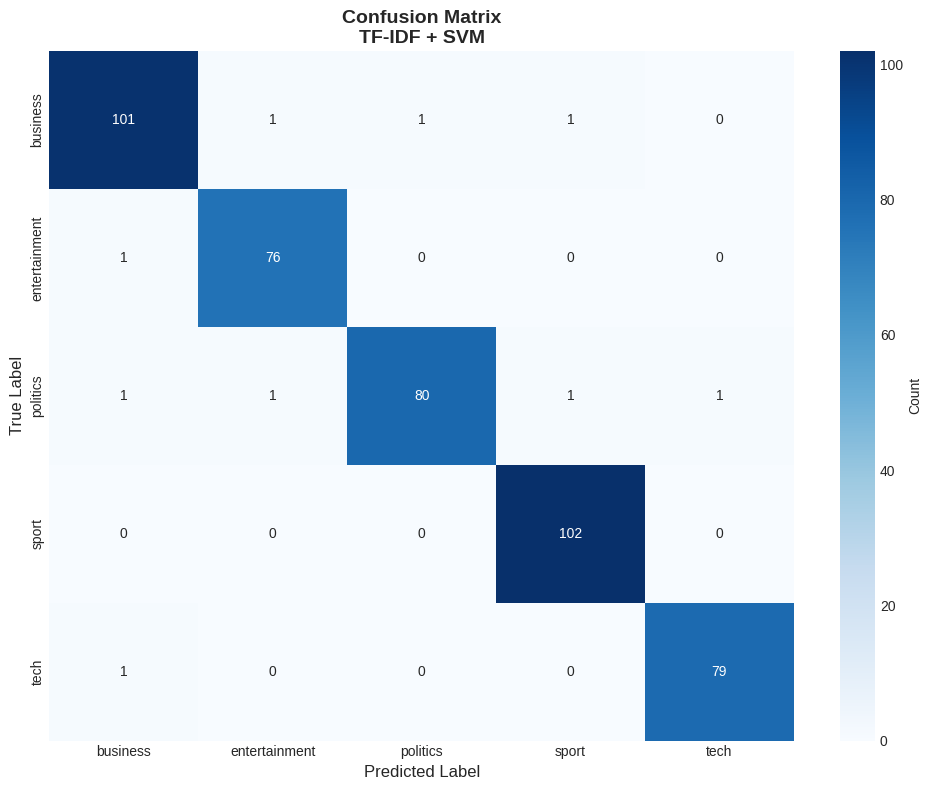

In [13]:
# extract best configuration
best_emb = best['Embedding']
best_model = best['Model']
cm = results[best_emb][best_model]['confusion_matrix']

# Plot confusion matrix
plt.figure(figsize=(10, 8))
labels = np.unique(y)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels, yticklabels=labels,
            cbar_kws={'label': 'Count'})
plt.title(f'Confusion Matrix\n{best_emb} + {best_model}',
         fontsize=14, fontweight='bold')
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.tight_layout()
plt.show()


### 13. Confusion Matrix of all configurations

---



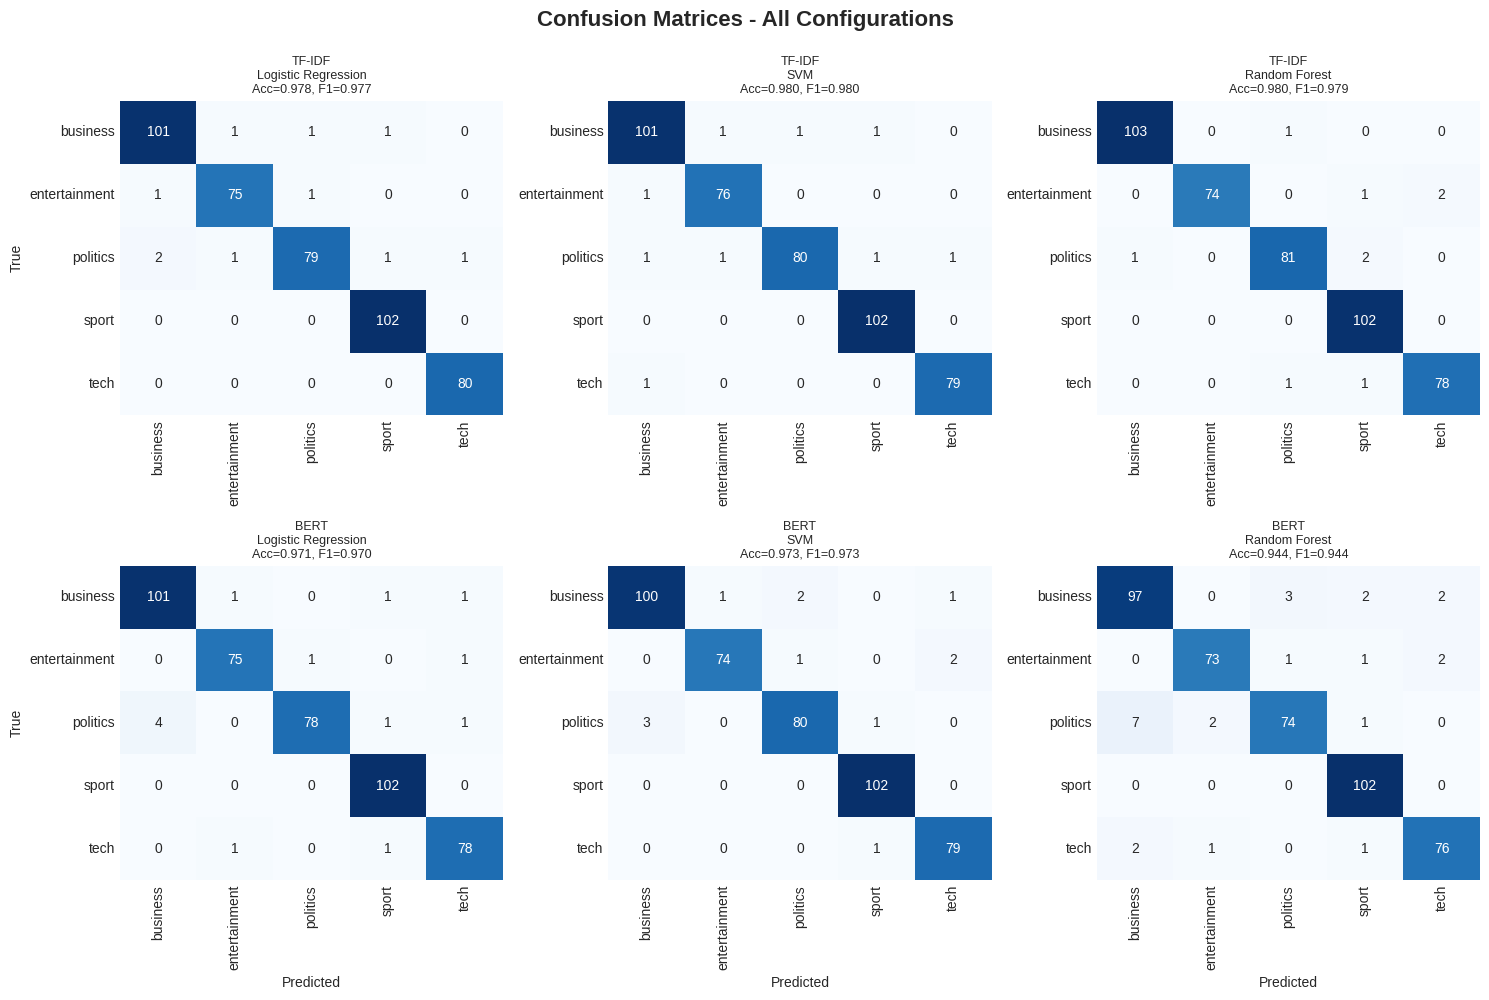

In [14]:
n_embeddings = len(embeddings)
n_models = len(models)

fig, axes = plt.subplots(n_embeddings, n_models, figsize=(15, 10))
fig.suptitle('Confusion Matrices - All Configurations',
            fontsize=16, fontweight='bold', y=0.995)

labels = np.unique(y)

for i, emb_name in enumerate(embeddings.keys()):
    for j, model_name in enumerate(models.keys()):
        cm = results[emb_name][model_name]['confusion_matrix']

        ax = axes[i, j] if n_embeddings > 1 else axes[j]

        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                   cbar=False, xticklabels=labels, yticklabels=labels)

        # title with metrics
        acc = results[emb_name][model_name]['accuracy']
        f1 = results[emb_name][model_name]['macro_f1']
        title = f'{emb_name}\n{model_name}\nAcc={acc:.3f}, F1={f1:.3f}'
        ax.set_title(title, fontsize=9)

        if j == 0:
            ax.set_ylabel('True', fontsize=10)
        if i == n_embeddings - 1:
            ax.set_xlabel('Predicted', fontsize=10)

plt.tight_layout()
plt.show()


## 14. Classification Report

In [15]:
# classification report for best configuration
print('='*80)
print(f'CLASSIFICATION REPORT')
print(f'Embedding: {best_emb} | Model: {best_model}')
print('='*80)

y_pred = results[best_emb][best_model]['predictions']
print(classification_report(y_test, y_pred, digits=4))


CLASSIFICATION REPORT
Embedding: TF-IDF | Model: SVM
               precision    recall  f1-score   support

     business     0.9712    0.9712    0.9712       104
entertainment     0.9744    0.9870    0.9806        77
     politics     0.9877    0.9524    0.9697        84
        sport     0.9808    1.0000    0.9903       102
         tech     0.9875    0.9875    0.9875        80

     accuracy                         0.9799       447
    macro avg     0.9803    0.9796    0.9799       447
 weighted avg     0.9799    0.9799    0.9798       447



## 15. Final Summary

---



In [16]:
print('\n' + '='*80)
print('FINAL SUMMARY')
print('='*80)

print(f'\n DATASET')
print(f'   Total samples: {len(y)}')
print(f'   Train samples: {len(y_train)}')
print(f'   Test samples: {len(y_test)}')
print(f'   Number of classes: {len(np.unique(y))}')

print(f'\n EMBEDDINGS TESTED')
for name, emb in embeddings.items():
    print(f'   {name:15s}: {emb.shape}')

print(f'\n MODELS TESTED')
for name in models.keys():
    print(f'   - {name}')

print(f'\n BEST CONFIGURATION')
print(f'   Embedding: {best["Embedding"]}')
print(f'   Model: {best["Model"]}')
print(f'   Accuracy: {best["Accuracy"]:.4f}')
print(f'   Macro F1: {best["Macro F1"]:.4f}')

print('\n' + '='*80)



FINAL SUMMARY

 DATASET
   Total samples: 2232
   Train samples: 1785
   Test samples: 447
   Number of classes: 5

 EMBEDDINGS TESTED
   TF-IDF         : (2232, 6985)
   BERT           : (2232, 384)

 MODELS TESTED
   - Logistic Regression
   - SVM
   - Random Forest

 BEST CONFIGURATION
   Embedding: TF-IDF
   Model: SVM
   Accuracy: 0.9799
   Macro F1: 0.9799

